
# Notebook 02 — Data Cleaning, Outlier Removal & Data Organization

## Objective

This notebook creates the **clean training/test boundary** for the Amazon ML Challenge product-length prediction project.

The main goals are:

1. Remove invalid records.
2. Remove duplicate records.
3. Detect and remove **right-tail target outliers**.
4. Analyze and remove **genuine left-tail target anomalies**.
5. Protect MAPE-sensitive small targets from being accidentally treated as outliers.
6. Clean text fields.
7. Parse product dimensions from text.
8. Normalize dimensions to centimetres.
9. Impute missing dimensions using training-only statistics.
10. Check train/test leakage and data integrity.
11. Save clean datasets and a complete cleaning audit.

> **Important:** Values such as `PRODUCT_LENGTH <= 10` are investigated first. They are **not automatically deleted**. A low target is removed only when it is statistically anomalous according to the learned lower-tail rule.


## 0. Configuration

In [1]:

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# DATA PATHS
# ------------------------------------------------------------
DATA_MODE = "debug"       # "debug" | "experiment" | "full"

DATA_PATHS = {
    "debug": "../dataset/sampled/debug",
    "experiment": "../dataset/sampled/experiment",
    "full": "../dataset"
}

DATA_DIR = DATA_PATHS[DATA_MODE]
OUTPUT_DIR = "../dataset/cleaned"

os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(DATA_DIR, "train.csv")
TEST_FILE = os.path.join(DATA_DIR, "test.csv")

CLEAN_TRAIN_FILE = os.path.join(
    OUTPUT_DIR, f"train_clean_{DATA_MODE}.csv"
)
CLEAN_TEST_FILE = os.path.join(
    OUTPUT_DIR, f"test_clean_{DATA_MODE}.csv"
)
AUDIT_FILE = os.path.join(
    OUTPUT_DIR, f"cleaning_audit_{DATA_MODE}.csv"
)
RULES_FILE = os.path.join(
    OUTPUT_DIR, f"cleaning_rules_{DATA_MODE}.json"
)

# ------------------------------------------------------------
# OUTLIER CONFIGURATION
# ------------------------------------------------------------

# Right-tail:
# log1p(target) > Q3 + multiplier * IQR
RIGHT_IQR_MULTIPLIER = 3.0

# Left-tail:
# log1p(target) < Q1 - multiplier * IQR
LEFT_IQR_MULTIPLIER = 3.0

# Do not remove small values merely because they hurt MAPE.
# A lower-tail observation must pass BOTH:
#   1. robust statistical lower-tail rule
#   2. minimum sample count / distribution sanity checks
MIN_LEFT_OUTLIER_COUNT = 1

# Optional absolute safety boundaries.
# Keep None unless EDA establishes a domain-specific boundary.
ABSOLUTE_TARGET_MIN = None
ABSOLUTE_TARGET_MAX = None

# Dimension sanity limit after conversion to cm.
MAX_DIMENSION_CM = 100000.0

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_DIR: ../dataset/sampled/debug
OUTPUT_DIR: ../dataset/cleaned


## 1. Load data

In [2]:

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)

print("Raw train shape:", train_raw.shape)
print("Raw test shape :", test_raw.shape)

display(train_raw.head(3))


Raw train shape: (50000, 6)
Raw test shape : (10000, 5)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
0,2028640,WHICHWOOD Wooden Handmade Ashok Stamb with Clock and Flag Desk Organizer for Office and Home Decoration (Brown),Purely high material |Ashok Stambh will definitely going to amuse your guests and visitors and will give royal touch...,"Wooden Ashoka pillar- National Emblem-Ashoka Stambh. Size: Height: 8"" Hand carved & Best quality wood used. Proper c...",8271,300.0
1,1369397,"Red and Black Throw Pillow Cushion Cover by Ambesonne, Poppy Field Spring Time Flower Grass Open Sky Photo, Decorati...","[18 INCHES x 18 INCHES - DOUBLE SIDED PRINT - With Zipper. Cut and sewn by hand. INSERT NOT INCLUDED,MADE FROM - 100...",Makeover and refresh your rooms with just a single touch! Start with these fun and decorative cushion cases. These u...,10324,1080.0
2,462899,Lives that Made Greek History,NaN,NaN,12482,550.0


## 2. Schema validation

In [3]:

REQUIRED_TRAIN = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID",
    "PRODUCT_LENGTH"
]

REQUIRED_TEST = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID"
]

missing_train = [c for c in REQUIRED_TRAIN if c not in train_raw.columns]
missing_test = [c for c in REQUIRED_TEST if c not in test_raw.columns]

assert not missing_train, f"Missing train columns: {missing_train}"
assert not missing_test, f"Missing test columns: {missing_test}"

assert "PRODUCT_LENGTH" not in test_raw.columns, (
    "PRODUCT_LENGTH found in test. This would be target leakage."
)

print("Schema validation PASSED.")


Schema validation PASSED.


## 3. Standardize dtypes

In [4]:

TEXT_COLS = ["TITLE", "BULLET_POINTS", "DESCRIPTION"]

def standardize_types(df, is_train=True):
    df = df.copy()

    df["PRODUCT_ID"] = df["PRODUCT_ID"].astype("string")

    df["PRODUCT_TYPE_ID"] = pd.to_numeric(
        df["PRODUCT_TYPE_ID"],
        errors="coerce"
    )

    for col in TEXT_COLS:
        df[col] = df[col].fillna("").astype("string")

    if is_train:
        df["PRODUCT_LENGTH"] = pd.to_numeric(
            df["PRODUCT_LENGTH"],
            errors="coerce"
        )

    return df

train = standardize_types(train_raw, is_train=True)
test = standardize_types(test_raw, is_train=False)

print(train.dtypes)


PRODUCT_ID          string
TITLE               string
BULLET_POINTS       string
DESCRIPTION         string
PRODUCT_TYPE_ID      int64
PRODUCT_LENGTH     float64
dtype: object


## 4. Cleaning audit

In [5]:

audit = pd.DataFrame({
    "PRODUCT_ID": train["PRODUCT_ID"].astype("string"),
    "removed": False,
    "reason": ""
}, index=train.index)

def mark_removed(mask, reason):
    mask = pd.Series(mask, index=train.index).fillna(False)

    # Do not overwrite an earlier, more fundamental reason.
    update_mask = mask & audit["reason"].eq("")
    audit.loc[update_mask, "removed"] = True
    audit.loc[update_mask, "reason"] = reason

print("Audit initialized.")


Audit initialized.


## 5. Duplicate removal

In [6]:

train_exact_dup = train.duplicated(keep="first")
train_id_dup = train["PRODUCT_ID"].duplicated(keep="first")

mark_removed(train_exact_dup, "exact_duplicate_row")
mark_removed(train_id_dup, "duplicate_product_id")

test_exact_dup = test.duplicated(keep="first")
test_id_dup = test["PRODUCT_ID"].duplicated(keep="first")

test = test.loc[~test_exact_dup & ~test_id_dup].copy()

print("Train exact duplicates:", train_exact_dup.sum())
print("Train duplicate IDs   :", train_id_dup.sum())
print("Test duplicate rows/IDs removed:", (test_exact_dup | test_id_dup).sum())


Train exact duplicates: 0
Train duplicate IDs   : 0
Test duplicate rows/IDs removed: 0


## 6. Invalid target removal

In [7]:

y = train["PRODUCT_LENGTH"]

missing_target = y.isna()
nonfinite_target = y.notna() & ~np.isfinite(y)
nonpositive_target = y.notna() & np.isfinite(y) & (y <= 0)

mark_removed(missing_target, "target_missing")
mark_removed(nonfinite_target, "target_non_finite")
mark_removed(nonpositive_target, "target_non_positive")

print("Missing target      :", missing_target.sum())
print("Non-finite target   :", nonfinite_target.sum())
print("Non-positive target :", nonpositive_target.sum())


Missing target      : 0
Non-finite target   : 0
Non-positive target : 0



# 7. MAPE-sensitive left-tail analysis

MAPE is extremely sensitive to small true target values.

Therefore we explicitly inspect the lower target region before removing anything.

These thresholds are **analysis buckets**, not automatic deletion rules.


In [8]:

valid_y = y[
    y.notna() &
    np.isfinite(y) &
    (y > 0)
].astype(float)

thresholds = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000]

left_analysis = []

n = len(valid_y)

for t in thresholds:
    count = int((valid_y <= t).sum())

    left_analysis.append({
        "threshold": t,
        "count": count,
        "percentage": count / n * 100 if n else 0
    })

left_analysis = pd.DataFrame(left_analysis)

display(left_analysis)


,threshold,count,percentage
0,1,37,0.074
1,2,86,0.172
2,3,90,0.180
3,5,141,0.282
4,10,223,0.446
5,20,313,0.626
6,50,1045,2.090
7,100,2162,4.324
8,200,3731,7.462
9,500,12184,24.368


## 8. Inspect smallest target observations

In [9]:

smallest_targets = train.loc[
    train["PRODUCT_LENGTH"].notna(),
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH", ascending=True)

display(smallest_targets.head(100))


,PRODUCT_ID,TITLE,BULLET_POINTS,PRODUCT_TYPE_ID,PRODUCT_LENGTH
25194,1653085,"Nike Women's Low-top Sneakers, Black/Anthracite, 8",sku=ar9293-006-8,3278,1.000
8581,1878984,"VECELO Upholstered Linen Fabric Surface,Meatl Frame/Woodboard/Inner Sponge,Headboards for Queen Bed,Dark Grey",[Free Adjustable Height- Has six height adjustable mounting positions from 41.9 inches to 49.7 inches to accommodate...,8304,1.000
20405,889167,Kukident Extra Strong Denture Adhesive Cream with Camomile Extract 1.41 Oz by Kukident,,10160,1.000
10347,1622828,"High-Strength Steel Hex Nut, Grade 8, Zinc Yellow-Chromate Plated, 5/8""-18 Thread Size","[Material Type: Medium Carbon,Made in China,Package Weight: 1.474 kilograms,Package Dimensions: 7.112 L x 14.478 H x...",8823,1.000
3071,1164636,"Wings Like Eagles Wall Decal (Dahlia Red, 27"" (H) X 35"" (W))","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",2577,1.000
...,...,...,...,...,...
49245,2052446,"StickerKing 3in1 Laptop Accessories Combo 15.6 Inch Sad Cat Laptop Skins Stickers, Mouse Pad and Palmrest Skin for H...","Laptop Accessories Combo Pack is Compatible with 15.6 INCH LAPTOPS , The Size of Laptop Skin Decal (LxH) : 15.2 x 10...",599,3.937
39543,2139601,"AMFIN® 15 x 35 Inch One Letter Foil Balloon for 1st Anniversary , 1 Month Baby Decoration / First Birthday Decoratio...","[You will receive 1 Pc. of 'one' Balloon.,This 'one' foil balloon is helium quality and suitable to inflate with bot...",1106,3.937
44482,657603,"Trois ans en Asie, 1855-1858",,1,3.937
24369,629762,Samidare t02 - lucifer and the biscuit hammer,,1,3.937



## 9. Learn robust lower and upper target boundaries

Because `PRODUCT_LENGTH` is positive and right-skewed, perform the outlier analysis in `log1p` space.

Upper boundary:

`Q3 + 3 × IQR`

Lower boundary:

`Q1 - 3 × IQR`

The lower boundary is converted back using `expm1`.

This means we do **not** delete every target below 10/20/50. Only values falling into the statistically extreme lower tail are candidates.


In [10]:

log_y = np.log1p(valid_y)

q1_log = float(log_y.quantile(0.25))
q3_log = float(log_y.quantile(0.75))
iqr_log = q3_log - q1_log

log_lower = q1_log - LEFT_IQR_MULTIPLIER * iqr_log
log_upper = q3_log + RIGHT_IQR_MULTIPLIER * iqr_log

robust_lower = float(np.expm1(log_lower))
robust_upper = float(np.expm1(log_upper))

if ABSOLUTE_TARGET_MIN is not None:
    final_lower = max(robust_lower, ABSOLUTE_TARGET_MIN)
else:
    final_lower = robust_lower

if ABSOLUTE_TARGET_MAX is not None:
    final_upper = min(robust_upper, ABSOLUTE_TARGET_MAX)
else:
    final_upper = robust_upper

print(f"log Q1                 : {q1_log:.6f}")
print(f"log Q3                 : {q3_log:.6f}")
print(f"log IQR                : {iqr_log:.6f}")
print()
print(f"Robust lower boundary  : {robust_lower:.6f}")
print(f"Robust upper boundary  : {robust_upper:.6f}")
print()
print(f"Final lower boundary   : {final_lower:.6f}")
print(f"Final upper boundary   : {final_upper:.6f}")


log Q1                 : 6.239907
log Q3                 : 6.988113
log IQR                : 0.748206

Robust lower boundary  : 53.341578
Robust upper boundary  : 10225.432638

Final lower boundary   : 53.341578
Final upper boundary   : 10225.432638


## 10. Identify left-tail and right-tail candidates

In [11]:

left_outlier = (
    train["PRODUCT_LENGTH"].notna()
    & np.isfinite(train["PRODUCT_LENGTH"])
    & (train["PRODUCT_LENGTH"] > 0)
    & (train["PRODUCT_LENGTH"] < final_lower)
)

right_outlier = (
    train["PRODUCT_LENGTH"].notna()
    & np.isfinite(train["PRODUCT_LENGTH"])
    & (train["PRODUCT_LENGTH"] > final_upper)
)

print("Left-tail candidates :", left_outlier.sum())
print("Right-tail candidates:", right_outlier.sum())

print("\nLeft-tail percentage:",
      left_outlier.sum() / len(train) * 100)

print("Right-tail percentage:",
      right_outlier.sum() / len(train) * 100)


Left-tail candidates : 1078
Right-tail candidates: 438

Left-tail percentage: 2.156
Right-tail percentage: 0.876


## 11. Inspect left-tail candidates before deletion

In [12]:

left_candidates = train.loc[
    left_outlier,
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "DESCRIPTION",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH")

print("Left-tail candidate rows:", len(left_candidates))
display(left_candidates.head(100))


Left-tail candidate rows: 1078


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
15707,1016440,Mommys Helper Bath Mitt With Loofa Sponge,,Mommys Helper Bath Mitt with Loofa Sponge,2324,1.000
31135,2203784,Golfer Gift Tumblers for Men - Large Travel Cup - Fun Gift for Golfers Coworkers,[FUN GOLFER GIFT STAINLESS STEEL TRAVEL TUMBLER: This large 30 oz stainless steel tumbler is sure to put a smile on ...,"This funny, custom designed stainless steel tumbler is the perfect gift for your favorite golfer. Could be for your ...",1424,1.000
27790,2727482,Wall posters for living room big size inspirational home decoration bedroom study room office cabin cafe Abstract Qu...,[Size: 14” X 11”; Glossy lamination on the front; Unframed; Printed on 300 GSM cardstock paper. These posters have D...,Wall posters for living room.,1557,1.000
16237,1971023,"Hepix Floral iPhone 12 Pro Clear Case White Rose Flowers iPhone 12 Max Cases, Slim Flexible Crystal TPU Phone Cover ...",[【Compatibility】Compatible with new iPhone 12 pro/max (6.1-inch). Not fit for any other device. The case is designed...,"Hepix Floral iPhone 12 Pro Clear Case White Rose Flowers iPhone 12 Max Cases, Slim Flexible Crystal TPU Phone Cover ...",12556,1.000
3071,1164636,"Wings Like Eagles Wall Decal (Dahlia Red, 27"" (H) X 35"" (W))","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",Wings Like Eagles Wall Decal is a great decal to make any wall in your home look great. Every order comes with simpl...,2577,1.000
...,...,...,...,...,...,...
13010,2412944,Amazon Brand - Inkast Denim Co. Men's Skinny Jeans (INK-SB-CL-SK-216_Grey-4_34),"[Classic 5 pocket Jeans with slight nicking for a lived in look,Soft stretchable cotton blend fabric for comfort and...",,2835,3.937
20681,2088816,Amazon Brand - Symbol Men's Printed Regular Fit Pyjamas (Pack of 2) Pajama Bottom (A2-SYMPJ-TEX-PO2-03_Black4&Maroon...,"[Machine Wash,Comfortable elastic waist band,Made in India,Printed,100% Fine cotton with softer handfeel]",,2842,3.937
48646,2325452,Amazon Brand - Symbol Men's Relaxed Fit Track Pants (TRK-02_Winter Moss_L),"[Comfortable elasticated waistband with draw cord,Two side pocket ane one back pocket,Quality fabric for comfort and...",,12829,3.937
24369,629762,Samidare t02 - lucifer and the biscuit hammer,,,1,3.937


## 12. Inspect right-tail candidates before deletion

In [13]:

right_candidates = train.loc[
    right_outlier,
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "DESCRIPTION",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH", ascending=False)

print("Right-tail candidate rows:", len(right_candidates))
display(right_candidates.head(100))


Right-tail candidate rows: 438


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
1625,2263460,TOPBATHY 1 Set Ladle Colander Spoon Stainless Steel Long Handle Soup Oil Separator Scoop Oil Filter Skimmer Spoon So...,"[gravy food fat separator They will bring you a good experience when you eat hot pot.,soup pan ladle Made of stainle...",<b> Features</b><br/><br/> Color: Silver<br/> material: Stainless steel<br/> Size: 28. 00X8. 20X2. 00cm/ 11. 00X3. 2...,11601,177408000.0
28060,1275322,Speedo Speedo Youth Big Boys' Rapid Splice Jammer Shorts Swimsuit,,,2275,9769000.0
45522,1562622,Dotti Ibiza Stripe Side Shirred Hoodie Tunic Cover-Up Black/White XL,"[DOTTI Size Chart,The DOTTI&#8482; Ibiza Stripe Side Shirred Hoodie Tunic Cover-Up is a must-have addition to your r...",DOTTI Size Chart The DOTTI&#8482; Ibiza Stripe Side Shirred Hoodie Tunic Cover-Up is a must-have addition to your re...,3072,9398900.0
8127,1404278,Spellbound Deep Plunge One Piece Swimsuit,"[Swim Systems By Sunsets,Turn heads this summer in our new Spellbound 1pc. Attention to detail is key with the small...",,3073,8542000.0
25097,791220,Speedo Sprint Swim Goggles (Black/Clear),"[Synthetic,Comes completely assembled with adjustable strap,Silicone strap for secure fit,Adjustable nose bridge so ...",The sprint for years was the standardpetitive swim goggles. The low-profilebined with a soft foam neoprene gasket ma...,4625,4935900.0
...,...,...,...,...,...,...
8210,1752647,"Rhino Mats, Diamond Plate Anti-Fatigue Mat, Vinyl, 3' x 25' x 9/16""",[Diamond Plate Anti-Fatigue mats is a strong performer that suffers no deterioration from weathering and ozone expos...,"Rhino Mats, Diamond Plate Anti-Fatigue Mats are The Benchmark For Comparison To All Other Industrial Anti-Fatigue Ma...",9146,30000.0
26068,2347363,"PureFit GRS Certified Recycled Blackout Curtains for Bedroom and Living Room, Thermal Insulated, Cold/Sun Blocking a...",[PACKAGE CONTENT & PRODUCT DIMENSIONS: Our recycled fabric blackout curtains are sold in pair (set of 2 curtain pane...,"<p><b>BECAUSE THERE IS NO PLANET B, WE LAUNCH RECYCLED CURTAINS</b></p><p><br></p><p>Us at PureFit through the Clima...",1649,29550.0
41633,1509732,"Custom Size Hallway Runner Rug, Slip Resistant, 26 Inch Wide x Your Choice of Length Size, Checkered Black, 26 Inch ...","[OEKO-TEX Certified / Polypyrene fabric / Light Weight / Skid Resistant / Anti-Static / Antibacterial / Mold, Mildew...",ORFA HOME's slip resistant rubber back custom size runners offer every home a tasteful selection of designs and vibr...,1636,28800.0
20218,2734712,Madoka Dark Grey Paper Weave Grasscloth Wallpaper,"[Unpasted paper weave grasscloth material,No repeat, random match,Dust and Vacuum and peelable,36-in by 24-ft long r...",,8438,28800.0



## 13. Final target cleaning policy

We now remove:

- missing target
- non-finite target
- non-positive target
- statistically extreme **left-tail** target
- statistically extreme **right-tail** target

We deliberately do **not** use MAPE as a reason to delete valid small products.

This prevents metric-driven data manipulation.


In [14]:

mark_removed(left_outlier, "extreme_left_target_outlier")
mark_removed(right_outlier, "extreme_right_target_outlier")

train_clean = train.loc[~audit["removed"]].copy()

print("Original train rows :", len(train))
print("Clean train rows    :", len(train_clean))
print("Rows removed        :", len(train) - len(train_clean))
print("Removal percentage  :",
      (len(train) - len(train_clean)) / len(train) * 100)

assert len(train_clean) > 0
assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()


Original train rows : 50000
Clean train rows    : 48484
Rows removed        : 1516
Removal percentage  : 3.032


## 14. Final target distribution after BOTH-tail cleaning

Clean target statistics
-----------------------
Minimum : 54.0
Q1      : 531.49606245
Median  : 669.2913379
Q3      : 1067.22280878275
Maximum : 10200.0
Mean    : 1044.6522739389532


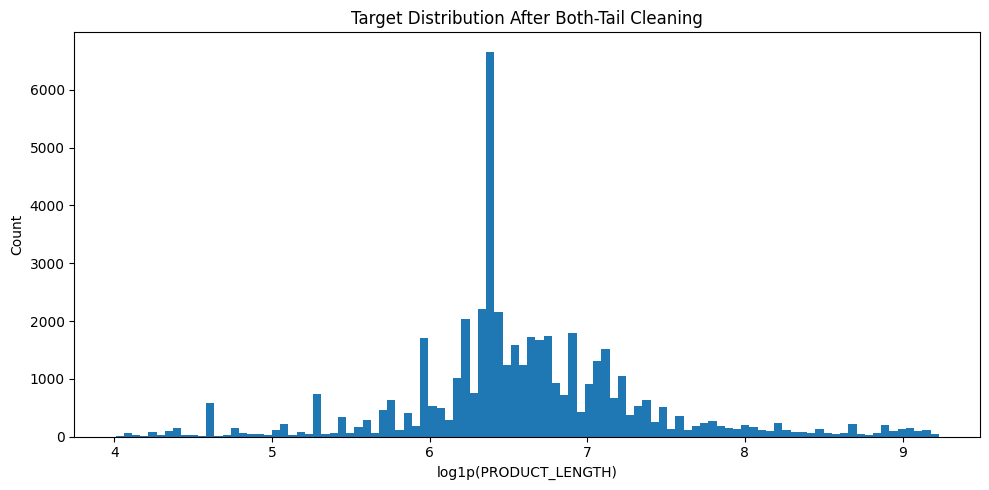

In [15]:

y_clean = train_clean["PRODUCT_LENGTH"].astype(float)

print("Clean target statistics")
print("-----------------------")
print("Minimum :", y_clean.min())
print("Q1      :", y_clean.quantile(0.25))
print("Median  :", y_clean.median())
print("Q3      :", y_clean.quantile(0.75))
print("Maximum :", y_clean.max())
print("Mean    :", y_clean.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(y_clean), bins=100)
ax.set_title("Target Distribution After Both-Tail Cleaning")
ax.set_xlabel("log1p(PRODUCT_LENGTH)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 15. Target buckets after cleaning

In [16]:

post_left_analysis = []

n_clean = len(y_clean)

for t in thresholds:
    count = int((y_clean <= t).sum())
    post_left_analysis.append({
        "threshold": t,
        "count": count,
        "percentage": count / n_clean * 100 if n_clean else 0
    })

post_left_analysis = pd.DataFrame(post_left_analysis)

display(post_left_analysis)


,threshold,count,percentage
0,1,0,0.000000
1,2,0,0.000000
2,3,0,0.000000
3,5,0,0.000000
4,10,0,0.000000
5,20,0,0.000000
6,50,0,0.000000
7,100,1084,2.235789
8,200,2653,5.471908
9,500,11106,22.906526


## 16. Text normalization

In [17]:

ZERO_WIDTH_RE = re.compile(r"[\u200B-\u200D\uFEFF]")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(s):
    s = s.fillna("").astype("string")
    s = s.str.replace(ZERO_WIDTH_RE, "", regex=True)
    s = s.str.replace("\r", " ", regex=False)
    s = s.str.replace("\n", " ", regex=False)
    s = s.str.replace(MULTISPACE_RE, " ", regex=True)
    s = s.str.strip()
    return s

for col in TEXT_COLS:
    train_clean[col] = clean_text(train_clean[col])
    test[col] = clean_text(test[col])

print("Text normalization complete.")


Text normalization complete.


## 17. Product ID and product type cleaning

In [18]:

bad_train_id = (
    train_clean["PRODUCT_ID"].isna()
    | train_clean["PRODUCT_ID"].str.strip().eq("")
)

bad_test_id = (
    test["PRODUCT_ID"].isna()
    | test["PRODUCT_ID"].str.strip().eq("")
)

print("Invalid train IDs:", bad_train_id.sum())
print("Invalid test IDs :", bad_test_id.sum())

train_clean = train_clean.loc[~bad_train_id].copy()
test = test.loc[~bad_test_id].copy()

# Unknown category rather than dropping the product.
train_clean["PRODUCT_TYPE_ID"] = (
    train_clean["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")
)

test["PRODUCT_TYPE_ID"] = (
    test["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")
)


Invalid train IDs: 0
Invalid test IDs : 0


## 18. Combined text for dimension extraction

In [19]:

def make_combined_text(df):
    return (
        df["TITLE"].fillna("").astype("string") + " " +
        df["BULLET_POINTS"].fillna("").astype("string") + " " +
        df["DESCRIPTION"].fillna("").astype("string")
    ).str.replace(r"\s+", " ", regex=True).str.strip()

train_clean["__TEXT_ALL"] = make_combined_text(train_clean)
test["__TEXT_ALL"] = make_combined_text(test)



## 19. Dimension parser

Extracts:

- `L`
- `W`
- `H`
- `L × W`
- `L × W × H`

and normalizes supported units to centimetres.


In [20]:

NUMBER = r"(\d+(?:\.\d+)?)"
UNIT = r"(mm|millimeters?|cm|centimeters?|m|meters?|in|inch(?:es)?|ft|feet|foot)"
SEP = r"(?:x|×|X|\*)"

DIM_RE = re.compile(
    rf"(?P<a>{NUMBER})\s*(?P<ua>{UNIT})?\s*{SEP}\s*"
    rf"(?P<b>{NUMBER})\s*(?P<ub>{UNIT})?"
    rf"(?:\s*{SEP}\s*(?P<c>{NUMBER})\s*(?P<uc>{UNIT})?)?",
    re.IGNORECASE
)

UNIT_TO_CM = {
    "mm": 0.1,
    "millimeter": 0.1,
    "millimeters": 0.1,
    "cm": 1.0,
    "centimeter": 1.0,
    "centimeters": 1.0,
    "m": 100.0,
    "meter": 100.0,
    "meters": 100.0,
    "in": 2.54,
    "inch": 2.54,
    "inches": 2.54,
    "ft": 30.48,
    "foot": 30.48,
    "feet": 30.48
}

def convert_to_cm(value, unit):
    value = float(value)

    if unit is None:
        return value

    return value * UNIT_TO_CM[unit.lower()]

def parse_dimension(text):
    matches = list(DIM_RE.finditer(str(text)))

    if not matches:
        return np.nan, np.nan, np.nan, 0

    # Prefer a 3-dimensional match.
    matches.sort(
        key=lambda m: (
            m.group("c") is not None,
            m.end() - m.start()
        ),
        reverse=True
    )

    m = matches[0]

    try:
        d1 = convert_to_cm(m.group("a"), m.group("ua"))
        d2 = convert_to_cm(m.group("b"), m.group("ub"))

        if m.group("c") is not None:
            d3 = convert_to_cm(m.group("c"), m.group("uc"))
            return d1, d2, d3, 3

        return d1, d2, np.nan, 2

    except Exception:
        return np.nan, np.nan, np.nan, 0

def extract_dimensions(series):
    parsed = series.map(parse_dimension)

    out = pd.DataFrame(
        parsed.tolist(),
        index=series.index,
        columns=[
            "DIM_1_CM",
            "DIM_2_CM",
            "DIM_3_CM",
            "DIM_COUNT"
        ]
    )

    out["DIM_PRODUCT_2D_CM2"] = (
        out["DIM_1_CM"] * out["DIM_2_CM"]
    )

    out["DIM_VOLUME_CM3"] = (
        out["DIM_1_CM"] *
        out["DIM_2_CM"] *
        out["DIM_3_CM"]
    )

    return out

train_dims = extract_dimensions(train_clean["__TEXT_ALL"])
test_dims = extract_dimensions(test["__TEXT_ALL"])

for col in train_dims.columns:
    train_clean[col] = train_dims[col]
    test[col] = test_dims[col]

display(train_clean[
    [
        "DIM_1_CM",
        "DIM_2_CM",
        "DIM_3_CM",
        "DIM_COUNT",
        "DIM_PRODUCT_2D_CM2",
        "DIM_VOLUME_CM3"
    ]
].head(10))


,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3
0,NaN,NaN,NaN,0,NaN,NaN
1,45.72,45.72,NaN,2,2090.3184,NaN
2,NaN,NaN,NaN,0,NaN,NaN
3,NaN,NaN,NaN,0,NaN,NaN
4,NaN,NaN,NaN,0,NaN,NaN
5,NaN,NaN,NaN,0,NaN,NaN
6,NaN,NaN,NaN,0,NaN,NaN
7,NaN,NaN,NaN,0,NaN,NaN
8,40.00,60.00,NaN,2,2400.0000,NaN
9,NaN,NaN,NaN,0,NaN,NaN


## 20. Dimension sanity checks

In [21]:

for df in [train_clean, test]:

    for col in ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]:

        bad = (
            df[col].notna()
            & (
                ~np.isfinite(df[col])
                | (df[col] <= 0)
                | (df[col] > MAX_DIMENSION_CM)
            )
        )

        df.loc[bad, col] = np.nan

    df["DIM_PRODUCT_2D_CM2"] = (
        df["DIM_1_CM"] * df["DIM_2_CM"]
    )

    df["DIM_VOLUME_CM3"] = (
        df["DIM_1_CM"] *
        df["DIM_2_CM"] *
        df["DIM_3_CM"]
    )

print("Dimension sanity checks complete.")


Dimension sanity checks complete.


## 21. Product-type-aware dimension imputation

In [22]:

DIM_COLS = ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]

global_dim_medians = {}
ptype_dim_medians = {}

for col in DIM_COLS:

    global_median = train_clean[col].median()

    if not np.isfinite(global_median):
        global_median = 1.0

    global_dim_medians[col] = float(global_median)

    medians = (
        train_clean
        .groupby("PRODUCT_TYPE_ID")[col]
        .median()
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    ptype_dim_medians[col] = {
        str(k): float(v)
        for k, v in medians.items()
    }

    train_clean[col] = train_clean[col].fillna(
        train_clean["PRODUCT_TYPE_ID"].map(medians)
    )

    test[col] = test[col].fillna(
        test["PRODUCT_TYPE_ID"].map(medians)
    )

    train_clean[col] = train_clean[col].fillna(global_median)
    test[col] = test[col].fillna(global_median)

for df in [train_clean, test]:

    df["DIM_PRODUCT_2D_CM2"] = (
        df["DIM_1_CM"] * df["DIM_2_CM"]
    )

    df["DIM_VOLUME_CM3"] = (
        df["DIM_1_CM"] *
        df["DIM_2_CM"] *
        df["DIM_3_CM"]
    )

print("Dimension imputation complete.")


Dimension imputation complete.


## 22. Dimension availability flags

In [23]:

train_clean["HAS_DIMENSION_2D"] = (
    train_dims["DIM_COUNT"] >= 2
).astype("int8")

train_clean["HAS_DIMENSION_3D"] = (
    train_dims["DIM_COUNT"] >= 3
).astype("int8")

test["HAS_DIMENSION_2D"] = (
    test_dims["DIM_COUNT"] >= 2
).astype("int8")

test["HAS_DIMENSION_3D"] = (
    test_dims["DIM_COUNT"] >= 3
).astype("int8")

print("Dimension flags added.")


Dimension flags added.


## 23. Text quality features

In [24]:

def add_text_quality_features(df):

    for col, prefix in [
        ("TITLE", "TITLE"),
        ("BULLET_POINTS", "BULLET"),
        ("DESCRIPTION", "DESC")
    ]:

        s = df[col].fillna("").astype("string")

        df[f"{prefix}_CHAR_COUNT"] = (
            s.str.len().fillna(0).astype("int32")
        )

        df[f"{prefix}_WORD_COUNT"] = (
            s.str.split().str.len().fillna(0).astype("int32")
        )

        df[f"{prefix}_DIGIT_COUNT"] = (
            s.str.count(r"\d").fillna(0).astype("int32")
        )

        df[f"{prefix}_EMPTY"] = (
            s.str.strip().eq("").astype("int8")
        )

    return df

train_clean = add_text_quality_features(train_clean)
test = add_text_quality_features(test)


## 24. Measurement-unit indicators

In [25]:

UNIT_RE = re.compile(
    r"\b(?:mm|millimeters?|cm|centimeters?|m|meters?|"
    r"in|inch(?:es)?|ft|feet|foot|kg|g|lb|lbs|oz)\b",
    re.IGNORECASE
)

for df in [train_clean, test]:

    df["HAS_MEASUREMENT_UNIT"] = (
        df["__TEXT_ALL"]
        .fillna("")
        .astype("string")
        .str.contains(UNIT_RE, regex=True, na=False)
        .astype("int8")
    )

print("Measurement indicators added.")


Measurement indicators added.


## 25. Train/test leakage checks

In [26]:

overlap = (
    set(train_clean["PRODUCT_ID"])
    & set(test["PRODUCT_ID"])
)

print("Train/Test PRODUCT_ID overlap:", len(overlap))

assert len(overlap) == 0
assert train_clean["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique

assert "PRODUCT_LENGTH" not in test.columns

assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()

print("Leakage checks PASSED.")


Train/Test PRODUCT_ID overlap: 0
Leakage checks PASSED.


## 26. Final data-quality report

In [27]:

def quality_report(df, name, target=False):

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Duplicate PRODUCT_ID:", df["PRODUCT_ID"].duplicated().sum())

    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    print("\nMissing values:")
    if len(missing):
        display(missing.to_frame("count"))
    else:
        print("None")

    if target:

        y = df["PRODUCT_LENGTH"]

        print("\nTarget statistics:")
        print("min    :", y.min())
        print("Q1     :", y.quantile(0.25))
        print("median :", y.median())
        print("Q3     :", y.quantile(0.75))
        print("max    :", y.max())
        print("mean   :", y.mean())

quality_report(train_clean, "CLEAN TRAIN", target=True)
quality_report(test, "CLEAN TEST", target=False)


CLEAN TRAIN
Shape: (48484, 28)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:
None

Target statistics:
min    : 54.0
Q1     : 531.49606245
median : 669.2913379
Q3     : 1067.22280878275
max    : 10200.0
mean   : 1044.6522739389532
CLEAN TEST
Shape: (10000, 27)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:
None


## 27. Cleaning summary

In [28]:

reason_summary = (
    audit[audit["removed"]]
    ["reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="count")
)

reason_summary["percentage_of_raw_train"] = (
    reason_summary["count"] / len(train) * 100
)

display(reason_summary)

print("\nTotal removed:", audit["removed"].sum())
print("Final train  :", len(train_clean))


,reason,count,percentage_of_raw_train
0,extreme_left_target_outlier,1078,2.156
1,extreme_right_target_outlier,438,0.876



Total removed: 1516
Final train  : 48484


## 28. Save cleaning rules

In [29]:

rules = {
    "data_mode": DATA_MODE,

    "target": {
        "column": "PRODUCT_LENGTH",
        "transform": "log1p",
        "left_rule": "Q1 - 3*IQR",
        "right_rule": "Q3 + 3*IQR",
        "log_q1": q1_log,
        "log_q3": q3_log,
        "log_iqr": iqr_log,
        "robust_lower": robust_lower,
        "robust_upper": robust_upper,
        "final_lower": final_lower,
        "final_upper": final_upper
    },

    "duplicates": {
        "exact_rows": "keep_first",
        "PRODUCT_ID": "keep_first"
    },

    "dimensions": {
        "unit": "cm",
        "max_dimension_cm": MAX_DIMENSION_CM,
        "imputation": "PRODUCT_TYPE_ID median -> global training median -> 1.0"
    },

    "text": {
        "missing_to_empty": True,
        "remove_zero_width_characters": True,
        "normalize_whitespace": True,
        "strip": True
    }
}

with open(RULES_FILE, "w", encoding="utf-8") as f:
    json.dump(rules, f, indent=2)

print("Saved:", RULES_FILE)


Saved: ../dataset/cleaned\cleaning_rules_debug.json


## 29. Remove internal parser text

In [30]:

# __TEXT_ALL is only an internal parsing helper.
# Notebook 04 will independently build the NLP text representation.

train_clean = train_clean.drop(columns=["__TEXT_ALL"])
test = test.drop(columns=["__TEXT_ALL"])

print("Internal helper column removed.")


Internal helper column removed.


## 30. Save final clean datasets and audit

In [31]:

train_clean.to_csv(CLEAN_TRAIN_FILE, index=False)
test.to_csv(CLEAN_TEST_FILE, index=False)

audit_to_save = audit.copy()
audit_to_save["original_row_index"] = audit_to_save.index

audit_to_save.to_csv(AUDIT_FILE, index=False)

print("Files written:")
print("  ", CLEAN_TRAIN_FILE)
print("  ", CLEAN_TEST_FILE)
print("  ", AUDIT_FILE)
print("  ", RULES_FILE)


Files written:
   ../dataset/cleaned\train_clean_debug.csv
   ../dataset/cleaned\test_clean_debug.csv
   ../dataset/cleaned\cleaning_audit_debug.csv
   ../dataset/cleaned\cleaning_rules_debug.json



# Notebook 02 Complete

The output of this notebook is the clean data boundary:

```text
dataset/cleaned/
├── train_clean_<mode>.csv
├── test_clean_<mode>.csv
├── cleaning_audit_<mode>.csv
└── cleaning_rules_<mode>.json
```

## Important modeling principle

Do **not** remove legitimate small products just to improve MAPE.

The purpose of the left-tail analysis is to identify **genuine anomalous/corrupted observations**, not to manipulate the evaluation metric.

After this notebook:

```text
Raw data
   ↓
Cleaning
   ├── invalid records
   ├── duplicates
   ├── left-tail anomalies
   └── right-tail anomalies
   ↓
Text normalization
   ↓
Dimension extraction
   ↓
Dimension normalization
   ↓
Training-only imputation
   ↓
Clean dataset
   ↓
Notebook 03 / NLP
```

The next stage can safely focus on **TF-IDF, character n-grams, numerical features, and model training**.
